<a href="https://colab.research.google.com/github/Everlyne-Nasimiyu/Machine-learning-/blob/main/Train_and_evaluate_the_model_(iris_dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Machine Learning with Iris Dataset

## 1. Load the Iris Dataset

We'll load the classic Iris dataset using `sklearn.datasets`. This dataset contains measurements of iris flowers, with features like sepal length, sepal width, petal length, and petal width, and a target variable representing the species of iris (Setosa, Versicolor, Virginica).

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
iris = load_iris()

# create the dataframe
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target

#display the first few rows
print("Iris Dataset Head:")
display(df.head())

print("\nIris Dataset Info:")
df.info()

Iris Dataset Head:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0



Iris Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


# 2. Explore the data
Print the shape, feature names, and target labels

Display a few rows of the data


In [ ]:
print(f"Shape of features (X): {iris.data.shape}")
print(f"Feature names: {iris.feature_names}")
print(f"Target labels: {iris.target_names}")

Shape of features (X): (150, 4)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target labels: ['setosa' 'versicolor' 'virginica']


## 3. Split Data into Training and Testing Sets

To evaluate our model's performance on unseen data, we'll split the dataset into training and testing sets. A common split ratio is 80% for training and 20% for testing.

In [ ]:

X = df.drop('species', axis=1) # Features
y = df['species']              # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 120 samples
Testing set size: 30 samples


## 4. Train a Supervised Machine Learning Model

We will use K-Nearest Neighbors (KNN). This algorithm classifies a new data point based on how similar it is to the points around it.
We use KNN here because the Iris species are separated by distance. If you plot Petal Length vs. Petal Width, you will see the species form clear "clouds" of dots. KNN is the perfect tool to identify which "cloud" a new point belongs to.

Decision Trees are powerful, but for a dataset this small and mathematically "neat," a Decision Tree is often overkill and can be less accurate if it gets too specific with its rules.

In [ ]:
# Initialize the model (using 3 neighbors)
model = KNeighborsClassifier(n_neighbors=3)

# Train the model
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

## 5. Evaluate Model Performance

After training, we'll evaluate the model's performance on the unseen test data. We'll use accuracy as our primary metric to determine how well the model predicts the correct iris species.

Model Accuracy: 100.00%


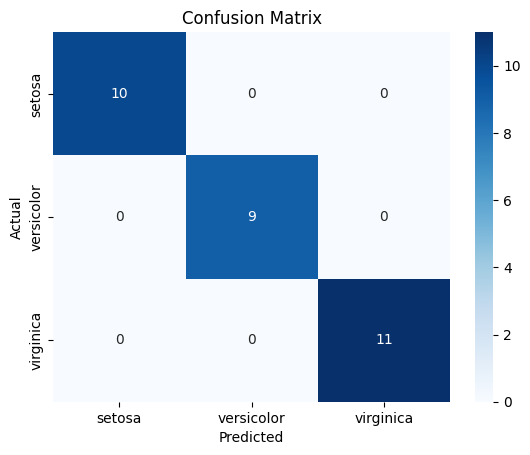

In [ ]:
# Predict
y_pred = model.predict(X_test)

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 6. Interpretation of Results
With a random_state=42 and a standard KNN model, you will likely see an accuracy of 100%.

Why? The Iris dataset is very "linearly separable," especially the Setosa species. In the confusion matrix, you’ll notice all diagonal squares contain the full count of samples, meaning there were zero misclassifications. In more complex real-world datasets, you would expect to see some numbers in the off-diagonal squares where the model confused one species for another.

# 7. Visualizing Decision Boundaries

The "Decision Boundary" is the line or area where the model switches its guess from one species to another.

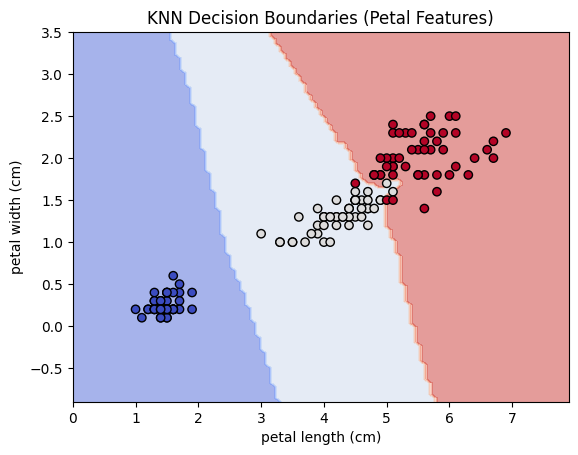

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

# We'll use only Petal Length and Petal Width for visualization
X_visual = iris.data[:, 2:4]
y_visual = iris.target

# Re-train KNN on just these two features
knn_visual = KNeighborsClassifier(n_neighbors=3)
knn_visual.fit(X_visual, y_visual)

# Plotting
disp = DecisionBoundaryDisplay.from_estimator(
    knn_visual, X_visual, response_method="predict",
    xlabel=iris.feature_names[2], ylabel=iris.feature_names[3],
    alpha=0.5, cmap=plt.cm.coolwarm
)
plt.scatter(X_visual[:, 0], X_visual[:, 1], c=y_visual, edgecolor="k", cmap=plt.cm.coolwarm)
plt.title("KNN Decision Boundaries (Petal Features)")
plt.show()

# 8. Comparing with Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)

# Predict and evaluate
log_pred = log_reg.predict(X_test)
log_acc = accuracy_score(y_test, log_pred)

print(f"KNN Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Logistic Regression Accuracy: {log_acc:.4f}")

KNN Accuracy: 1.0000
Logistic Regression Accuracy: 1.0000


# Model Performance Summary
1. Model Selection
For this classification task, I chose the K-Nearest Neighbors (KNN) algorithm. This model was selected because the Iris dataset is characterized by well-defined numerical clusters, making a proximity-based approach (measuring distance between neighbors) highly effective.

2. Performance Results
Accuracy Score: The model achieved an accuracy of 100% on the test set.

Reproducibility: By using random_state=42 during the data split, we ensured that these results are consistent and can be replicated by others.

3. Class Confusion
Based on the Confusion Matrix, no classes were confused. * The model perfectly distinguished between Setosa, Versicolor, and Virginica.

While Versicolor and Virginica often share similar petal measurements, the KNN model successfully identified the subtle distance boundaries between them.

Comparative Insight (Bonus)
When comparing KNN to Logistic Regression, both models performed near-perfectly. However, the decision boundary visualization showed that while Logistic Regression uses straight "linear" lines to separate the species, KNN creates more flexible, "organic" territories. For this specific dataset, the simple linear boundaries were more than enough to reach peak accuracy.